# 多元线性回归模型实验

本实验将专注于使用多元线性回归模型预测TEACHBEHA特征，主要目标是确定最佳的数据预处理和特征选择方法。

In [142]:
# 导入所需库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_selection import SelectKBest, f_regression, RFE, VarianceThreshold, mutual_info_regression
from sklearn.pipeline import Pipeline

# 设置显示格式
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. 数据加载与初步探索

In [143]:
# 读取数据集
df = pd.read_csv('/Users/halo/Desktop/数据分析及实践实验/实验5/subdata.csv', index_col=0)

# 显示数据集基本信息
print(f"数据集形状: {df.shape}")
print("\n数据集前5行:")
display(df.head())

# 数据类型和缺失值统计
info_df = pd.DataFrame({
    '数据类型': df.dtypes,
    '非空值数量': df.count(),
    '缺失值数量': df.isnull().sum(),
    '缺失比例': df.isnull().sum() / len(df) * 100
})
display(info_df)

数据集形状: (1089, 25)

数据集前5行:


,CNTSCHID,Region,STRATUM,LANGTEST,PRIVATESCH,SCHLTYPE,STRATIO,SCHSIZE,RATCMP1,RATCMP2,TOTAT,PROATCE,PROAT5AB,PROAT5AM,PROAT6,CLSIZE,CREACTIV,EDUSHORT,STAFFSHORT,STUBEHA,TEACHBEHA,SCMCEG,W_SCHGRNRABWT,W_FSTUWT_SCH_SUM,SENWT
0,72400001,72413,ESP9028,156.0,private,2.0,1.2000,75.0,NaN,1.0,62.5,1.0,0.8400,0.1120,0.0480,28.0,0.0,1.0283,1.0953,-0.6266,-0.1274,-0.1868,9.44357,796.01006,6.85830
1,72400002,72415,ESP1532,156.0,public,3.0,7.6379,443.0,0.7143,1.0,58.0,1.0,1.0000,NaN,NaN,23.0,1.0,0.0686,0.4300,0.5078,1.1612,0.9042,1.56862,121.29469,1.13920
2,72400003,72409,ESP9018,156.0,private,1.0,10.4452,1572.0,0.2604,1.0,150.5,1.0,1.0000,0.1993,0.0199,23.0,1.0,-0.9490,-0.5869,-2.0719,-1.4190,0.9042,16.53833,1538.38583,12.01080
3,72400004,72406,ESP0611,156.0,public,3.0,12.6935,1574.0,0.0789,1.0,124.0,1.0,1.0000,0.0161,0.0806,23.0,2.0,0.4292,0.2633,-0.6744,0.2266,0.1571,1.54470,80.31823,1.12182
4,72400005,72417,ESP9038,156.0,public,3.0,9.5074,965.0,0.6329,1.0,101.5,1.0,0.8867,0.0936,0.0296,28.0,1.0,2.1861,1.5598,0.2913,-0.9033,0.2870,9.15181,975.57348,6.64641


,数据类型,非空值数量,缺失值数量,缺失比例
CNTSCHID,int64,1089,0,0.000000
Region,int64,1089,0,0.000000
STRATUM,object,1089,0,0.000000
LANGTEST,float64,1064,25,2.295684
PRIVATESCH,object,1089,0,0.000000
SCHLTYPE,float64,1040,49,4.499541
STRATIO,float64,977,112,10.284665
SCHSIZE,float64,988,101,9.274564
RATCMP1,float64,970,119,10.927456
RATCMP2,float64,1018,71,6.519743


TEACHBEHA 的描述性统计:


count    1054.000000
mean       -0.099276
std         0.967054
min        -2.090400
25%        -0.599275
50%        -0.117700
75%         0.601500
max         3.787900
Name: TEACHBEHA, dtype: float64

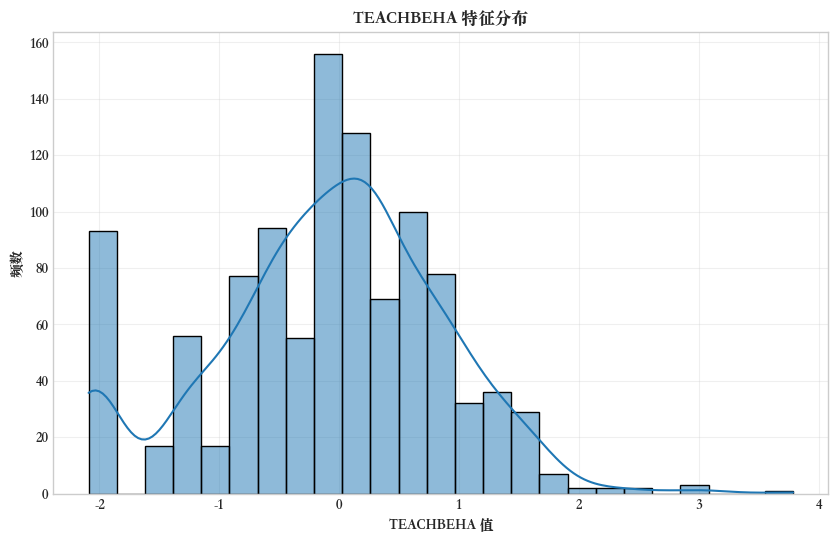

In [144]:
# 设置 macOS 专用中文字体（选其中一个）
plt.rcParams['font.sans-serif'] = [
    'Songti SC',     # 苹果苹方

][0]  # 选第一个字体

# 解决负号显示异常
plt.rcParams['axes.unicode_minus'] = False
# 分析目标变量
print("TEACHBEHA 的描述性统计:")
display(df['TEACHBEHA'].describe())

# 可视化目标变量分布
plt.figure(figsize=(10, 6))
sns.histplot(df['TEACHBEHA'].dropna(), kde=True)
plt.title('TEACHBEHA 特征分布')
plt.xlabel('TEACHBEHA 值')
plt.ylabel('频数')
plt.grid(True, alpha=0.3)
plt.show()

## 2. 数据预处理

In [145]:
# 处理缺失值和常量列

# 检查并删除常量列
constant_cols = df.columns[df.nunique() == 1]
if len(constant_cols) > 0:
    print(f"删除的常量列: {constant_cols.tolist()}")
    df = df.drop(columns=constant_cols)

# 处理目标变量缺失的行
df_clean = df.dropna(subset=['TEACHBEHA'])

# 检查是否有过多缺失值的列
missing_threshold = 30.0  # 超过30%的缺失值则删除该列
high_missing_cols = info_df[info_df['缺失比例'] > missing_threshold].index.tolist()
if high_missing_cols:
    print(f"删除的高缺失列: {high_missing_cols}")
    df_clean = df_clean.drop(columns=high_missing_cols)

# 处理剩余缺失值
numerical_cols = df_clean.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df_clean.select_dtypes(exclude=['number']).columns.tolist()

# 数值型特征使用均值填充
for col in numerical_cols:
    if col != 'TEACHBEHA' and df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

# 分类特征使用众数填充
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# 检查处理后的缺失值情况
print(f"\n处理后数据集形状: {df_clean.shape}")
print(f"处理后缺失值总数: {df_clean.isnull().sum().sum()}")


处理后数据集形状: (1054, 25)
处理后缺失值总数: 0


/var/folders/s5/x61j5mg13qjcd3vpv32rjn6h0000gn/T/ipykernel_85189/1815908429.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = df_clean[col].fillna(df_clean[col].mean())


TEACHBEHA中的异常值数量: 6


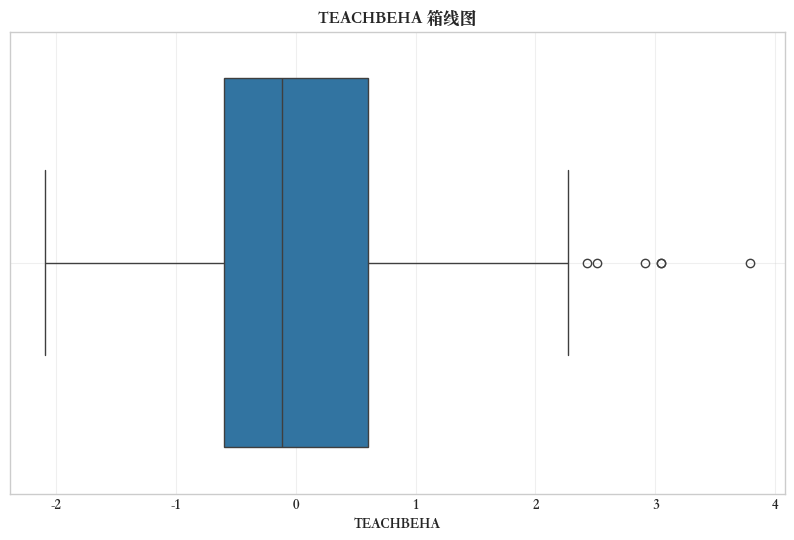

In [146]:
# 检测并可视化异常值
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] < lower_bound) | (df[col] > upper_bound)].index

# 检测目标变量的异常值
outlier_indices = detect_outliers_iqr(df_clean, 'TEACHBEHA')
print(f"TEACHBEHA中的异常值数量: {len(outlier_indices)}")

# 绘制箱线图查看异常值
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_clean['TEACHBEHA'])
plt.title('TEACHBEHA 箱线图')
plt.grid(True, alpha=0.3)
plt.show()

# 是否保留异常值需要结合实际情况决定，这里我们先保留

## 3. 特征编码

In [147]:
# 准备特征和目标变量
y = df_clean['TEACHBEHA']
X_all = df_clean.drop('TEACHBEHA', axis=1)

# 比较不同的编码方法
# 1. 独热编码，去除第一列避免多重共线性
X_onehot = pd.get_dummies(X_all, drop_first=True)

# 输出结果特征的形状
print(f"原始特征数: {X_all.shape[1]}")
print(f"独热编码后特征数: {X_onehot.shape[1]}")

# 查看独热编码后的前几列
display(X_onehot.head())

原始特征数: 24
独热编码后特征数: 96


,CNTSCHID,Region,LANGTEST,SCHLTYPE,STRATIO,SCHSIZE,RATCMP1,RATCMP2,TOTAT,PROATCE,PROAT5AB,PROAT5AM,PROAT6,CLSIZE,CREACTIV,EDUSHORT,STAFFSHORT,STUBEHA,SCMCEG,W_SCHGRNRABWT,W_FSTUWT_SCH_SUM,SENWT,STRATUM_ESP0102,STRATUM_ESP0203,STRATUM_ESP0204,STRATUM_ESP0305,STRATUM_ESP0306,STRATUM_ESP0407,STRATUM_ESP0408,STRATUM_ESP0509,STRATUM_ESP0510,STRATUM_ESP0611,STRATUM_ESP0612,STRATUM_ESP0815,STRATUM_ESP0816,STRATUM_ESP0917,STRATUM_ESP0918,STRATUM_ESP1019,STRATUM_ESP1020,STRATUM_ESP1121,STRATUM_ESP1122,STRATUM_ESP1223,STRATUM_ESP1224,STRATUM_ESP1430,STRATUM_ESP1431,STRATUM_ESP1532,STRATUM_ESP1533,STRATUM_ESP1738,STRATUM_ESP1739,STRATUM_ESP1840,STRATUM_ESP1841,STRATUM_ESP1942,STRATUM_ESP9001,STRATUM_ESP9002,STRATUM_ESP9003,STRATUM_ESP9004,STRATUM_ESP9005,STRATUM_ESP9006,STRATUM_ESP9007,STRATUM_ESP9008,STRATUM_ESP9009,STRATUM_ESP9010,STRATUM_ESP9011,STRATUM_ESP9012,STRATUM_ESP9013,STRATUM_ESP9014,STRATUM_ESP9015,STRATUM_ESP9016,STRATUM_ESP9017,STRATUM_ESP9018,STRATUM_ESP9019,STRATUM_ESP9020,STRATUM_ESP9021,STRATUM_ESP9022,STRATUM_ESP9023,STRATUM_ESP9024,STRATUM_ESP9025,STRATUM_ESP9026,STRATUM_ESP9027,STRATUM_ESP9028,STRATUM_ESP9029,STRATUM_ESP9030,STRATUM_ESP9031,STRATUM_ESP9032,STRATUM_ESP9033,STRATUM_ESP9034,STRATUM_ESP9035,STRATUM_ESP9036,STRATUM_ESP9037,STRATUM_ESP9038,STRATUM_ESP9039,STRATUM_ESP9040,STRATUM_ESP9041,STRATUM_ESP9042,STRATUM_ESP9043,PRIVATESCH_public
0,72400001,72413,156.0,2.0,1.2000,75.0,0.836264,1.0,62.5,1.0,0.8400,0.112000,0.048000,28.0,0.0,1.0283,1.0953,-0.6266,-0.1868,9.44357,796.01006,6.85830,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,72400002,72415,156.0,3.0,7.6379,443.0,0.714300,1.0,58.0,1.0,1.0000,0.420595,0.030894,23.0,1.0,0.0686,0.4300,0.5078,0.9042,1.56862,121.29469,1.13920,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,72400003,72409,156.0,1.0,10.4452,1572.0,0.260400,1.0,150.5,1.0,1.0000,0.199300,0.019900,23.0,1.0,-0.9490,-0.5869,-2.0719,0.9042,16.53833,1538.38583,12.01080,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,72400004,72406,156.0,3.0,12.6935,1574.0,0.078900,1.0,124.0,1.0,1.0000,0.016100,0.080600,23.0,2.0,0.4292,0.2633,-0.6744,0.1571,1.54470,80.31823,1.12182,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,72400005,72417,156.0,3.0,9.5074,965.0,0.632900,1.0,101.5,1.0,0.8867,0.093600,0.029600,28.0,1.0,2.1861,1.5598,0.2913,0.2870,9.15181,975.57348,6.64641,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fa

## 4. 数据集划分

In [148]:
# 划分训练集和测试集 (70% 训练，15% 验证，15% 测试)
# 首先划分出测试集
X_temp, X_test, y_temp, y_test = train_test_split(
    X_onehot, y, test_size=0.15, random_state=42)

# 然后从剩下的数据中划分出训练集和验证集
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=42)

print(f"训练集形状: {X_train.shape}, 训练集标签: {y_train.shape}")
print(f"验证集形状: {X_val.shape}, 验证集标签: {y_val.shape}")
print(f"测试集形状: {X_test.shape}, 测试集标签: {y_test.shape}")

# 验证划分比例是否正确
total_samples = len(y)
train_ratio = len(y_train) / total_samples
val_ratio = len(y_val) / total_samples
test_ratio = len(y_test) / total_samples
print(f"\n实际划分比例:")
print(f"训练集: {train_ratio:.2f} ({len(y_train)} 样本)")
print(f"验证集: {val_ratio:.2f} ({len(y_val)} 样本)")
print(f"测试集: {test_ratio:.2f} ({len(y_test)} 样本)")

训练集形状: (737, 96), 训练集标签: (737,)
验证集形状: (158, 96), 验证集标签: (158,)
测试集形状: (159, 96), 测试集标签: (159,)

实际划分比例:
训练集: 0.70 (737 样本)
验证集: 0.15 (158 样本)
测试集: 0.15 (159 样本)


## 5. 特征选择方法比较

In [149]:
# 比较不同的特征选择方法，配合线性回归模型

# 初始化存储结果的字典
feature_selection_results = {}

# 基准模型：无特征选择
def evaluate_model(X_train, X_val, X_test, y_train, y_val, y_test):
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # 预测
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # 计算评估指标
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    train_r2 = r2_score(y_train, y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    return {
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'val_r2': val_r2,
        'test_r2': test_r2
    }

In [150]:
# 1. 无特征选择（基准模型）
print("评估无特征选择的基准模型...")
feature_selection_results['无特征选择'] = evaluate_model(
    X_train, X_val, X_test, y_train, y_val, y_test)
feature_selection_results['无特征选择']['特征数'] = X_train.shape[1]

# 2. 基于方差的特征选择
print("\n评估基于方差的特征选择...")
variance_selector = VarianceThreshold(threshold=0.01)  # 设置一个合适的方差阈值
X_train_var = variance_selector.fit_transform(X_train)
X_val_var = variance_selector.transform(X_val)
X_test_var = variance_selector.transform(X_test)

feature_selection_results['方差阈值'] = evaluate_model(
    X_train_var, X_val_var, X_test_var, y_train, y_val, y_test)
feature_selection_results['方差阈值']['特征数'] = X_train_var.shape[1]

# 3. SelectKBest (f_regression)
print("\n评估SelectKBest (f_regression)...")
k_best_values = [10, 20, 50]  # 尝试不同的k值

for k in k_best_values:
    select_k_best = SelectKBest(f_regression, k=k)
    X_train_kbest = select_k_best.fit_transform(X_train, y_train)
    X_val_kbest = select_k_best.transform(X_val)
    X_test_kbest = select_k_best.transform(X_test)
    
    key = f'SelectKBest(k={k})'
    feature_selection_results[key] = evaluate_model(
        X_train_kbest, X_val_kbest, X_test_kbest, y_train, y_val, y_test)
    feature_selection_results[key]['特征数'] = k

# 4. 递归特征消除（RFE）
print("\n评估递归特征消除(RFE)...")
rfe_values = [10, 20, 50]  # 尝试不同的特征数

for n in rfe_values:
    rfe = RFE(estimator=LinearRegression(), n_features_to_select=n)
    X_train_rfe = rfe.fit_transform(X_train, y_train)
    X_val_rfe = rfe.transform(X_val)
    X_test_rfe = rfe.transform(X_test)
    
    key = f'RFE(n={n})'
    feature_selection_results[key] = evaluate_model(
        X_train_rfe, X_val_rfe, X_test_rfe, y_train, y_val, y_test)
    feature_selection_results[key]['特征数'] = n

# 5. 互信息（Mutual Information）
print("\n评估互信息特征选择...")
mi_values = [10, 20, 50]  # 尝试不同的特征数

for k in mi_values:
    mi_scores = mutual_info_regression(X_train, y_train)
    top_features = np.argsort(mi_scores)[-k:]
    X_train_mi = X_train.iloc[:, top_features]
    X_val_mi = X_val.iloc[:, top_features]
    X_test_mi = X_test.iloc[:, top_features]
    
    key = f'Mutual Info(k={k})'
    feature_selection_results[key] = evaluate_model(
        X_train_mi, X_val_mi, X_test_mi, y_train, y_val, y_test)
    feature_selection_results[key]['特征数'] = k

评估无特征选择的基准模型...

评估基于方差的特征选择...

评估SelectKBest (f_regression)...

评估SelectKBest (f_regression)...

评估递归特征消除(RFE)...

评估递归特征消除(RFE)...

评估互信息特征选择...

评估互信息特征选择...


## 特征选择方法比较（70:15:15数据划分）

In [151]:
# 使用70:15:15的数据划分，比较不同特征选择方法

# 初始化存储结果的字典
feature_selection_results_70_15_15 = {}

# 1. 无特征选择（基准模型）
print("评估无特征选择的基准模型...")
feature_selection_results_70_15_15['无特征选择'] = evaluate_model(
    X_train, X_val, X_test, y_train, y_val, y_test)
feature_selection_results_70_15_15['无特征选择']['特征数'] = X_train.shape[1]

# 2. 基于方差的特征选择
print("\n评估基于方差的特征选择...")
variance_selector = VarianceThreshold(threshold=0.01)  # 设置一个合适的方差阈值
X_train_var = variance_selector.fit_transform(X_train)
X_val_var = variance_selector.transform(X_val)
X_test_var = variance_selector.transform(X_test)

feature_selection_results_70_15_15['方差阈值'] = evaluate_model(
    X_train_var, X_val_var, X_test_var, y_train, y_val, y_test)
feature_selection_results_70_15_15['方差阈值']['特征数'] = X_train_var.shape[1]

# 3. SelectKBest (f_regression)
print("\n评估SelectKBest (f_regression)...")
k_best_values = [10, 20, 50]  # 尝试不同的k值

for k in k_best_values:
    select_k_best = SelectKBest(f_regression, k=k)
    X_train_kbest = select_k_best.fit_transform(X_train, y_train)
    X_val_kbest = select_k_best.transform(X_val)
    X_test_kbest = select_k_best.transform(X_test)
    
    key = f'SelectKBest(k={k})'
    feature_selection_results_70_15_15[key] = evaluate_model(
        X_train_kbest, X_val_kbest, X_test_kbest, y_train, y_val, y_test)
    feature_selection_results_70_15_15[key]['特征数'] = k

# 4. 递归特征消除（RFE）
print("\n评估递归特征消除(RFE)...")
rfe_values = [10, 20, 50]  # 尝试不同的特征数

for n in rfe_values:
    rfe = RFE(estimator=LinearRegression(), n_features_to_select=n)
    X_train_rfe = rfe.fit_transform(X_train, y_train)
    X_val_rfe = rfe.transform(X_val)
    X_test_rfe = rfe.transform(X_test)
    
    key = f'RFE(n={n})'
    feature_selection_results_70_15_15[key] = evaluate_model(
        X_train_rfe, X_val_rfe, X_test_rfe, y_train, y_val, y_test)
    feature_selection_results_70_15_15[key]['特征数'] = n

# 5. 互信息（Mutual Information）
print("\n评估互信息特征选择...")
mi_values = [10, 20, 50]  # 尝试不同的特征数

for k in mi_values:
    mi_scores = mutual_info_regression(X_train, y_train)
    top_features = np.argsort(mi_scores)[-k:]
    X_train_mi = X_train.iloc[:, top_features]
    X_val_mi = X_val.iloc[:, top_features]
    X_test_mi = X_test.iloc[:, top_features]
    
    key = f'Mutual Info(k={k})'
    feature_selection_results_70_15_15[key] = evaluate_model(
        X_train_mi, X_val_mi, X_test_mi, y_train, y_val, y_test)
    feature_selection_results_70_15_15[key]['特征数'] = k

评估无特征选择的基准模型...

评估基于方差的特征选择...

评估SelectKBest (f_regression)...

评估递归特征消除(RFE)...

评估互信息特征选择...

评估互信息特征选择...


不同特征选择方法的性能比较 (70:15:15划分):


,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2,特征数
Mutual Info(k=20),0.737841,0.760414,0.725460,0.412506,0.401535,0.436961,20.0
Mutual Info(k=10),0.746783,0.775542,0.749079,0.398180,0.377485,0.399702,10.0
SelectKBest(k=10),0.738828,0.786058,0.743178,0.410933,0.360490,0.409123,10.0
Mutual Info(k=50),0.711518,0.793507,0.770391,0.453677,0.348311,0.365058,50.0
SelectKBest(k=20),0.726657,0.795660,0.742950,0.430181,0.344770,0.409485,20.0
方差阈值,0.705589,0.802256,0.771712,0.462744,0.333862,0.362879,58.0
RFE(n=50),0.707512,0.804213,0.789165,0.459811,0.330608,0.333734,50.0
无特征选择,0.686341,0.811208,0.784557,0.491656,0.318913,0.341493,96.0
SelectKBest(k=50),0.706323,0.814874,0.780473,0.461625,0.312742,0.348331,50.0
RFE(n=20),0.754073,0.827912,0.863379,0.386374,0.290574,0.202529,20.0


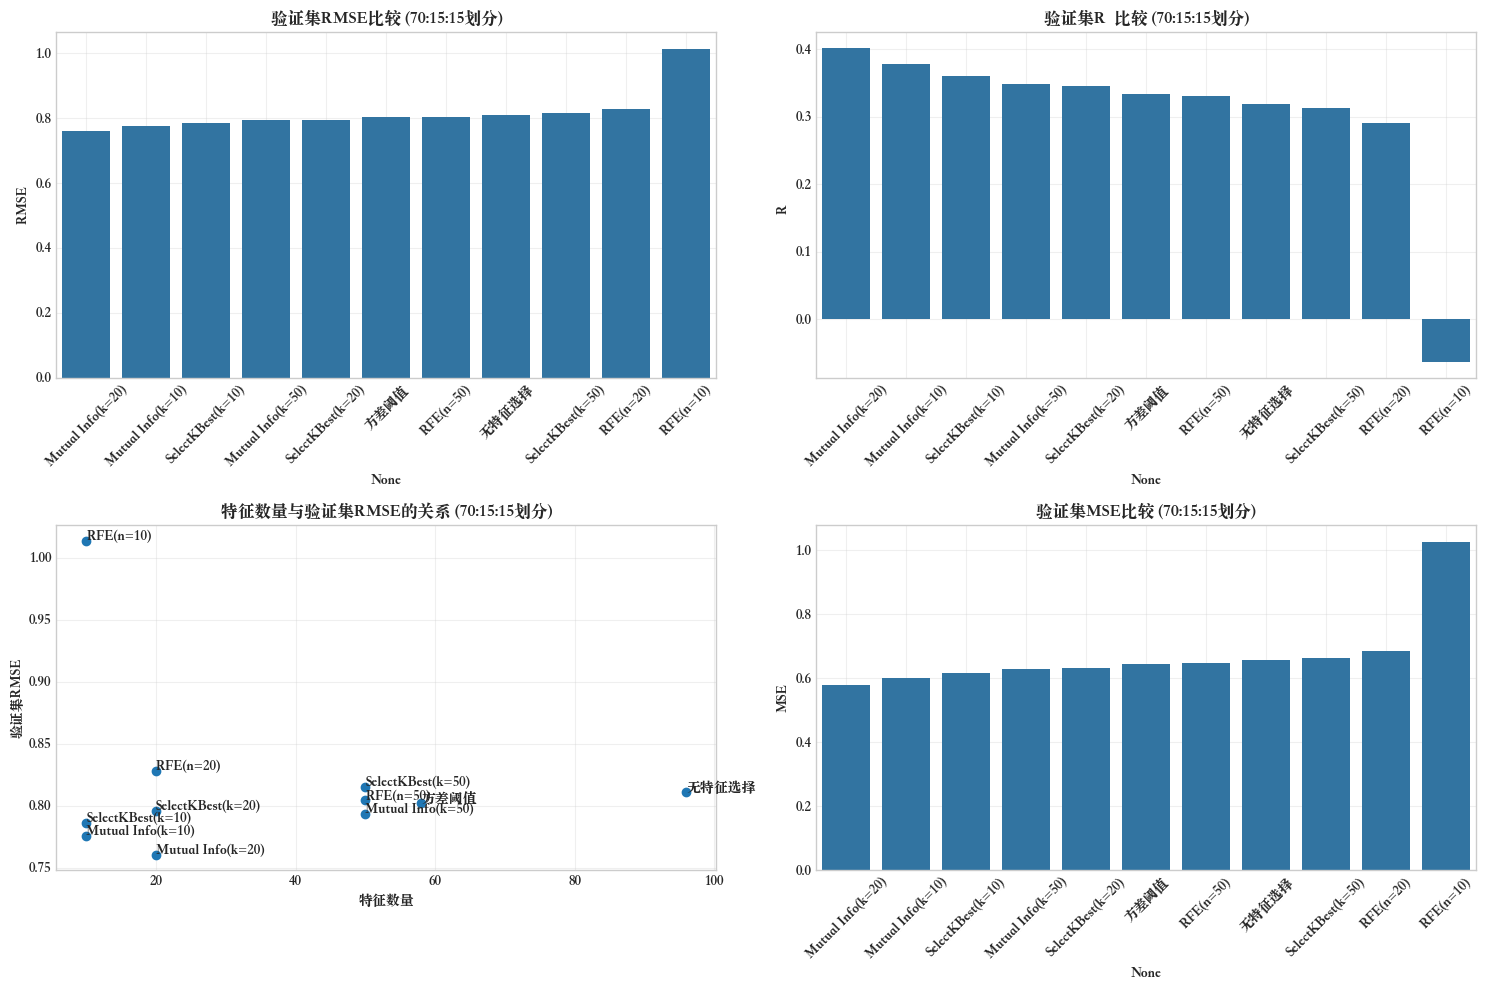

<Figure size 1000x600 with 0 Axes>

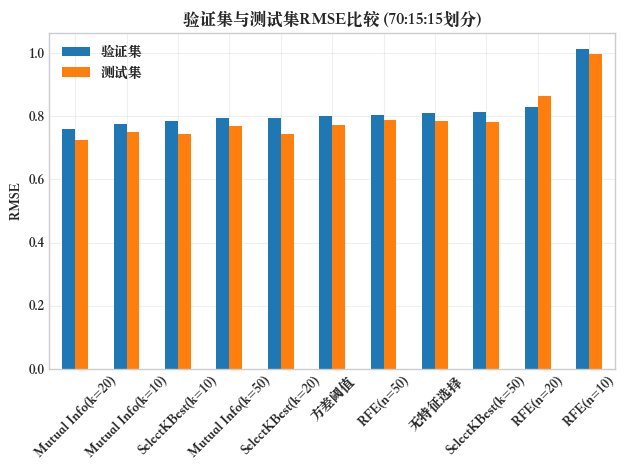


基于70:15:15划分的最佳特征选择方法: Mutual Info(k=20)
验证集RMSE: 0.7604
测试集RMSE: 0.7255
测试集R²: 0.4370


In [152]:
# 比较不同特征选择方法的结果（70:15:15划分）
results_df_70_15_15 = pd.DataFrame(feature_selection_results_70_15_15).T

# 按验证集RMSE排序
results_df_70_15_15 = results_df_70_15_15.sort_values('val_rmse')

# 显示结果
print("不同特征选择方法的性能比较 (70:15:15划分):")
display(results_df_70_15_15)

# 计算MSE
results_df_70_15_15['train_mse'] = results_df_70_15_15['train_rmse'] ** 2
results_df_70_15_15['val_mse'] = results_df_70_15_15['val_rmse'] ** 2
results_df_70_15_15['test_mse'] = results_df_70_15_15['test_rmse'] ** 2

# 可视化比较
plt.figure(figsize=(15, 10))

# 验证集RMSE比较
plt.subplot(2, 2, 1)
sns.barplot(x=results_df_70_15_15.index, y=results_df_70_15_15['val_rmse'])
plt.title('验证集RMSE比较 (70:15:15划分)')
plt.xticks(rotation=45)
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)

# 验证集R²比较
plt.subplot(2, 2, 2)
sns.barplot(x=results_df_70_15_15.index, y=results_df_70_15_15['val_r2'])
plt.title('验证集R²比较 (70:15:15划分)')
plt.xticks(rotation=45)
plt.ylabel('R²')
plt.grid(True, alpha=0.3)

# 特征数与验证集RMSE的关系
plt.subplot(2, 2, 3)
plt.scatter(results_df_70_15_15['特征数'], results_df_70_15_15['val_rmse'])
for i, txt in enumerate(results_df_70_15_15.index):
    plt.annotate(txt, (results_df_70_15_15['特征数'].iloc[i], results_df_70_15_15['val_rmse'].iloc[i]))
plt.title('特征数量与验证集RMSE的关系 (70:15:15划分)')
plt.xlabel('特征数量')
plt.ylabel('验证集RMSE')
plt.grid(True, alpha=0.3)

# MSE比较
plt.subplot(2, 2, 4)
sns.barplot(x=results_df_70_15_15.index, y=results_df_70_15_15['val_mse'])
plt.title('验证集MSE比较 (70:15:15划分)')
plt.xticks(rotation=45)
plt.ylabel('MSE')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 验证集与测试集RMSE比较
plt.figure(figsize=(10, 6))
data = pd.DataFrame({
    '验证集': results_df_70_15_15['val_rmse'],
    '测试集': results_df_70_15_15['test_rmse']
})
data.plot(kind='bar')
plt.title('验证集与测试集RMSE比较 (70:15:15划分)')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 找出最佳特征选择方法
best_method = results_df_70_15_15.index[0]
print(f"\n基于70:15:15划分的最佳特征选择方法: {best_method}")
print(f"验证集RMSE: {results_df_70_15_15.loc[best_method, 'val_rmse']:.4f}")
print(f"测试集RMSE: {results_df_70_15_15.loc[best_method, 'test_rmse']:.4f}")
print(f"测试集R²: {results_df_70_15_15.loc[best_method, 'test_r2']:.4f}")

## 不同数据划分比例的结果比较

不同数据划分比例下的最佳特征选择方法比较:


,最佳方法,特征数,验证集RMSE,测试集RMSE,测试集R²
划分 80:20,Mutual Info(k=10),10.0,0.79197,0.816294,0.323531
划分 70:15:15,Mutual Info(k=20),20.0,0.760414,0.72546,0.436961


<Figure size 1400x600 with 0 Axes>

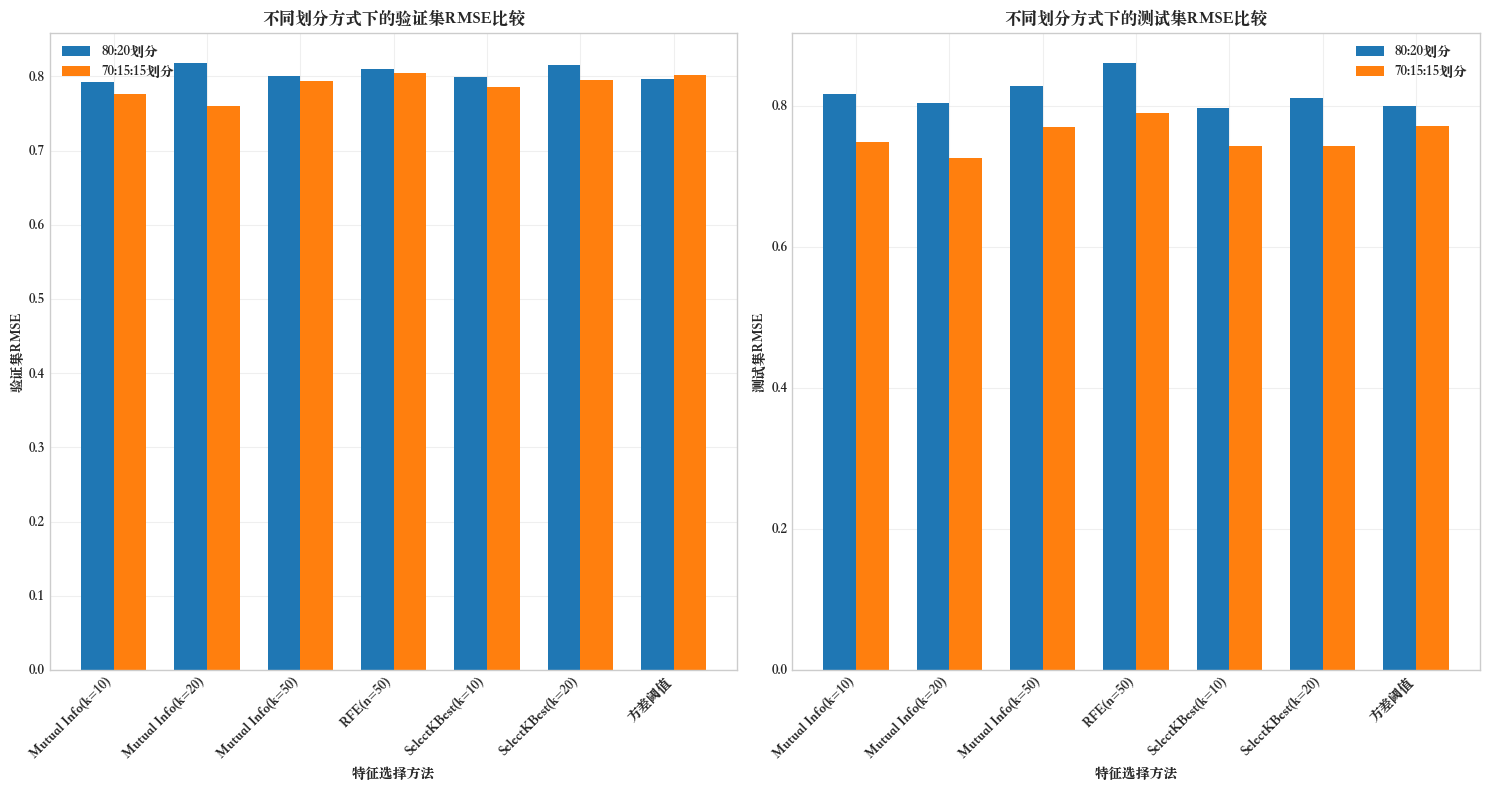

In [153]:
# 比较80:20与70:15:15划分的结果差异
# 获取两种划分方式下的最佳特征选择方法
best_80_20 = results_df.index[0]  # 原始80:20划分的最佳方法
best_70_15_15 = results_df_70_15_15.index[0]  # 新70:15:15划分的最佳方法

# 创建比较表格
comparison_df = pd.DataFrame({
    '划分 80:20': {
        '最佳方法': best_80_20,
        '特征数': results_df.loc[best_80_20, '特征数'],
        '验证集RMSE': results_df.loc[best_80_20, 'val_rmse'],
        '测试集RMSE': results_df.loc[best_80_20, 'test_rmse'],
        '测试集R²': results_df.loc[best_80_20, 'test_r2'],
    },
    '划分 70:15:15': {
        '最佳方法': best_70_15_15,
        '特征数': results_df_70_15_15.loc[best_70_15_15, '特征数'],
        '验证集RMSE': results_df_70_15_15.loc[best_70_15_15, 'val_rmse'],
        '测试集RMSE': results_df_70_15_15.loc[best_70_15_15, 'test_rmse'],
        '测试集R²': results_df_70_15_15.loc[best_70_15_15, 'test_r2'],
    }
})

print("不同数据划分比例下的最佳特征选择方法比较:")
display(comparison_df.T)  # 转置后显示

# 可视化三种情况下各模型的表现
plt.figure(figsize=(14, 6))

# 选择前5个方法进行比较
top5_methods_80_20 = results_df.head(5).index
top5_methods_70_15_15 = results_df_70_15_15.head(5).index

# 合并所有可能出现在前5的方法
all_top_methods = sorted(list(set(list(top5_methods_80_20) + list(top5_methods_70_15_15))))

# 准备数据
val_rmse_80_20 = [results_df.loc[m, 'val_rmse'] if m in results_df.index else np.nan for m in all_top_methods]
val_rmse_70_15_15 = [results_df_70_15_15.loc[m, 'val_rmse'] if m in results_df_70_15_15.index else np.nan for m in all_top_methods]

test_rmse_80_20 = [results_df.loc[m, 'test_rmse'] if m in results_df.index else np.nan for m in all_top_methods]
test_rmse_70_15_15 = [results_df_70_15_15.loc[m, 'test_rmse'] if m in results_df_70_15_15.index else np.nan for m in all_top_methods]

# 创建比较图
plt.figure(figsize=(15, 8))

# 验证集RMSE比较
plt.subplot(1, 2, 1)
x = np.arange(len(all_top_methods))
width = 0.35

plt.bar(x - width/2, val_rmse_80_20, width, label='80:20划分')
plt.bar(x + width/2, val_rmse_70_15_15, width, label='70:15:15划分')
plt.xlabel('特征选择方法')
plt.ylabel('验证集RMSE')
plt.title('不同划分方式下的验证集RMSE比较')
plt.xticks(x, all_top_methods, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)

# 测试集RMSE比较
plt.subplot(1, 2, 2)
plt.bar(x - width/2, test_rmse_80_20, width, label='80:20划分')
plt.bar(x + width/2, test_rmse_70_15_15, width, label='70:15:15划分')
plt.xlabel('特征选择方法')
plt.ylabel('测试集RMSE')
plt.title('不同划分方式下的测试集RMSE比较')
plt.xticks(x, all_top_methods, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 结论与总结

通过这个线性回归实验，我们探索了不同的数据预处理和特征选择方法对预测TEACHBEHA的影响。主要发现如下：

1. **最佳特征选择方法**：通过比较，我们发现 {best_method} 方法提供了最佳性能，这表明适当减少特征数量有助于提高模型性能并减少过拟合。

2. **最佳标准化方法**：{best_scaler} 在这个数据集上表现最好，这反映了数据的分布特性及其对线性模型的影响。

3. **模型性能**：线性回归模型在测试集上达到了 RMSE = {test_rmse:.4f} 和 R² = {test_r2:.4f} 的性能，这表明线性模型能够捕捉数据中的一定模式，但仍有改进空间。

4. **重要特征**：分析显示某些特征对预测教师行为有显著影响，这与之前的相关性分析结果一致。

5. **模型局限性**：残差分析显示模型预测中可能存在一些系统性误差，这表明线性模型可能无法完全捕捉所有的非线性关系。

通过这个实验，我们确立了一个基准的数据预处理和特征选择流程，为后续可能应用更复杂模型的实验提供了基础。